<a href="https://colab.research.google.com/github/Lovie-Tonimba/semester4-DataMining/blob/main/latihanJobsheet12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import io
uploaded = files.upload()

Saving DatasetSIB2GbyLovie.csv to DatasetSIB2GbyLovie.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv(io.BytesIO(uploaded['DatasetSIB2GbyLovie.csv']))

In [26]:
df['Tinggi_m'] = df['Tinggi badan'] / 100
df['BMI'] = df['Berat badan'] / (df['Tinggi_m'] ** 2)

def cek_status(bmi):
    if 18.5 <= bmi <= 24.9:
        return 'Ideal'
    else:
        return 'Tidak Ideal'

df['Status BMI'] = df['BMI'].apply(cek_status)

print(df['Status BMI'].value_counts())

Status BMI
Ideal          14
Tidak Ideal     7
Name: count, dtype: int64


In [28]:
X = df[['Tinggi badan', 'Berat badan']]
y = df['Status BMI']

#Membagi Data Training dan Data Testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
classifier_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
classifier_dt.fit(X_train, y_train)

pred_dt = classifier_dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)
print(f"Akurasi Decision Tree: {acc_dt * 100:.2f}%")

Akurasi Decision Tree: 80.00%


In [30]:
#KNN - Perbandingan Jarak
k_values = [1, 3, 5, 7]
jarak_metrik = ['minkowski', 'euclidean']

print("PERBANDINGAN KNN")

for k in k_values:
    print(f"\nUntuk K = {k}:")
    for metrik in jarak_metrik:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metrik)

        knn.fit(X_train, y_train)

        pred_knn = knn.predict(X_test)

        acc_knn = accuracy_score(y_test, pred_knn)
        print(f"Akurasi menggunakan {metrik.capitalize()}: {acc_knn * 100:.2f}%")

PERBANDINGAN KNN

Untuk K = 1:
Akurasi menggunakan Minkowski: 100.00%
Akurasi menggunakan Euclidean: 100.00%

Untuk K = 3:
Akurasi menggunakan Minkowski: 60.00%
Akurasi menggunakan Euclidean: 60.00%

Untuk K = 5:
Akurasi menggunakan Minkowski: 60.00%
Akurasi menggunakan Euclidean: 60.00%

Untuk K = 7:
Akurasi menggunakan Minkowski: 60.00%
Akurasi menggunakan Euclidean: 60.00%


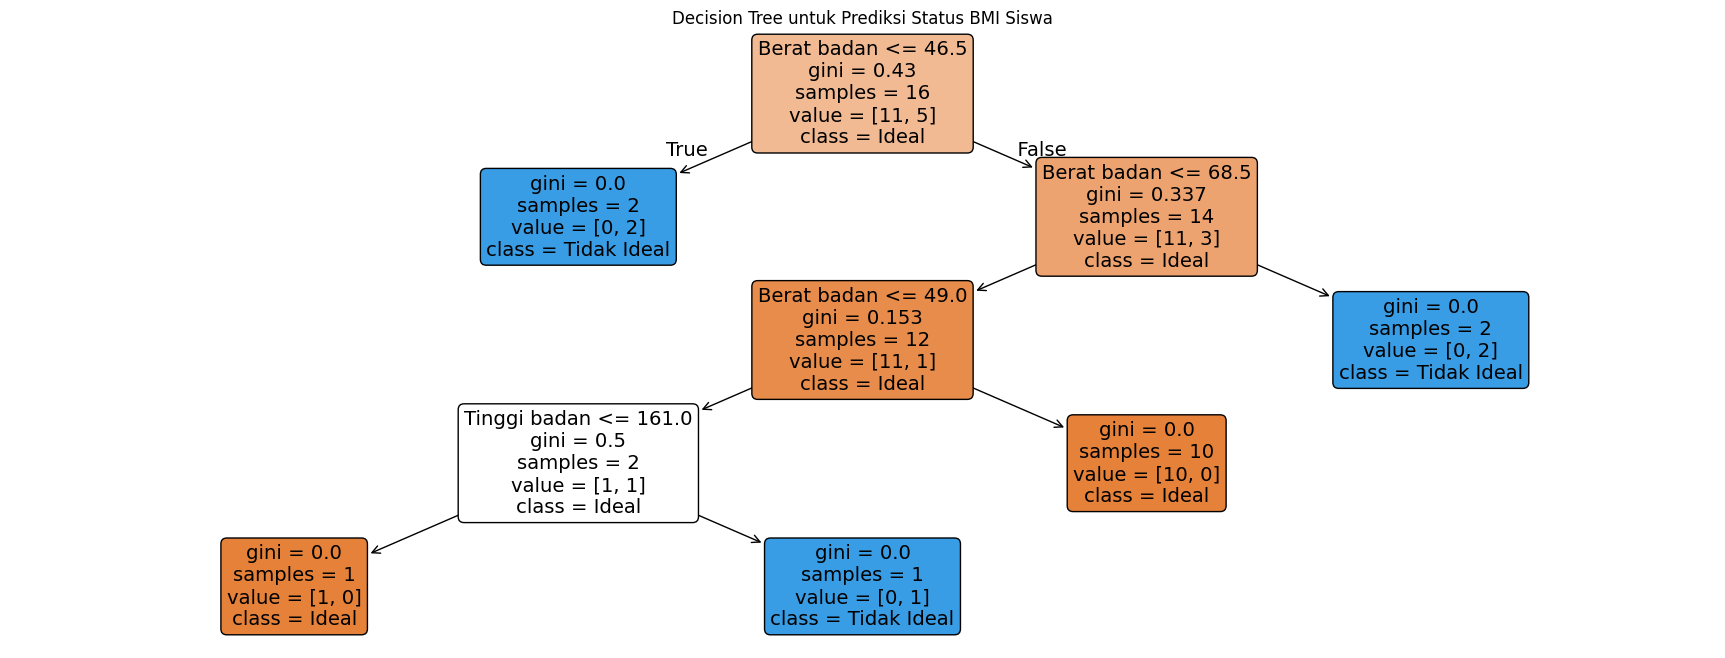

In [31]:
plt.figure(figsize=(22, 8))
plot_tree(classifier_dt,
          feature_names=['Tinggi badan', 'Berat badan'],
          class_names=classifier_dt.classes_,
          filled=True,
          rounded=True)
plt.title("Decision Tree untuk Prediksi Status BMI Siswa")
plt.show()